In [155]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sps
import math
import itertools as it
from sklearn.preprocessing import power_transform
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')

# Credit Card Fraud Dataset - Exploratory Data Analysis

## Loading the Data

In [156]:
data = pd.read_csv('../data/train.csv')

In [157]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [158]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213605 entries, 0 to 213604
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    213605 non-null  float64
 1   V1      213605 non-null  float64
 2   V2      213605 non-null  float64
 3   V3      213605 non-null  float64
 4   V4      213605 non-null  float64
 5   V5      213605 non-null  float64
 6   V6      213605 non-null  float64
 7   V7      213605 non-null  float64
 8   V8      213605 non-null  float64
 9   V9      213605 non-null  float64
 10  V10     213605 non-null  float64
 11  V11     213605 non-null  float64
 12  V12     213605 non-null  float64
 13  V13     213605 non-null  float64
 14  V14     213605 non-null  float64
 15  V15     213605 non-null  float64
 16  V16     213605 non-null  float64
 17  V17     213605 non-null  float64
 18  V18     213605 non-null  float64
 19  V19     213605 non-null  float64
 20  V20     213605 non-null  float64
 21  V21     21

In [159]:
data.Time = data.Time.astype('timedelta64[s]')

The [description](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) of the dataset on Kaggle states that the features V1 - V28 are principal components generated by a PCA, and would therefore hold less interpretable information to do with the credit card transactions themselves. There are no missing values that need to be dealt with, but the Time column can be changed to a timedelta format to more clearly show the time elapsed since the first transaction recorded in the dataset.

We can extract the hour information from the time column (which is in seconds elapsed) to check for periodic trends.

In [160]:
data['Hour'] = data.Time.dt.components.hours

In [161]:
data.drop(columns=['Class']).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time,213605,0 days 20:47:07,0 days 10:19:12,0 days 00:00:00,0 days 12:45:59,0 days 19:28:51,1 days 07:26:03,1 days 14:42:00
V1,213605.0,-0.081436,1.912503,-56.40751,-0.953611,-0.057441,1.228667,2.45493
V2,213605.0,-0.005202,1.633525,-72.715728,-0.590494,0.074764,0.781193,22.057729
V3,213605.0,0.248385,1.46945,-33.680984,-0.458745,0.431247,1.185352,9.382558
V4,213605.0,0.058455,1.404922,-5.683171,-0.810027,0.059332,0.860617,16.875344
V5,213605.0,-0.084781,1.364302,-42.147898,-0.765257,-0.144345,0.501945,34.801666
V6,213605.0,0.039402,1.315821,-26.160506,-0.720556,-0.227572,0.439678,22.529298
V7,213605.0,-0.036601,1.21831,-43.557242,-0.571394,0.00082,0.51914,36.677268
V8,213605.0,0.009877,1.204628,-73.216718,-0.18861,0.037731,0.334542,20.007208
V9,213605.0,0.005876,1.129835,-13.434066,-0.662653,-0.070575,0.61967,15.594995


In [162]:
data['Class'].value_counts()

Class
0    213207
1       398
Name: count, dtype: int64

Because of the number of records in the dataset, as well as the class imbalance, we will take 30 second windows of time around every positive case for the analysis.

In [163]:
data = data.set_index('Time')

In [164]:
fraud_timestamps = data[data['Class'] == 1].index
window_size = pd.Timedelta(seconds=15)

samples = [data.loc[time - window_size:time + window_size] for time in fraud_timestamps]

sample = pd.concat(samples).drop_duplicates()

In [165]:
sample

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
Time,,,,,,,,,,,,,,,,,,,,,
0 days 00:06:31,-0.829932,0.430250,1.303708,1.040559,0.822210,0.844830,0.589865,0.045791,-0.148645,0.310523,...,0.096038,-0.139415,-0.859739,0.121235,-0.204962,-0.292247,-0.058996,27.70,0,0
0 days 00:06:32,-2.153491,0.104021,1.459532,-1.613284,-1.071361,0.192161,-0.332748,0.462717,-0.209569,0.237996,...,0.096735,-0.490325,-0.392662,0.608578,-0.338382,-0.352132,-0.422726,82.29,0,0
0 days 00:06:33,-2.595500,1.311592,1.323081,-1.127849,0.307467,-0.518202,-2.098817,-4.382469,1.724535,0.198680,...,-0.835845,-1.786329,0.485594,-0.535158,-0.684143,-0.422542,0.047078,64.04,0,0
0 days 00:06:34,1.293053,0.457969,-1.940450,0.173149,2.609570,3.014117,-0.269415,0.754420,-0.221009,-0.620800,...,-0.427753,-0.159336,0.857135,0.850055,-0.311685,0.037536,0.050618,1.00,0,0
0 days 00:06:34,-0.553092,1.667591,-0.047357,0.514249,0.589388,-0.635411,1.126611,-0.311882,0.035247,1.704936,...,0.687658,-0.076693,0.014810,-0.590713,-0.482998,0.137717,-0.334915,1.55,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1 days 14:38:50,-0.755848,0.540022,0.767730,0.839153,1.572756,0.038987,0.316354,-0.118354,-0.492462,-0.244951,...,-0.488756,-0.508259,0.078108,0.544246,-0.282145,0.097039,0.041176,1.00,0,14
1 days 14:38:50,-0.572907,-0.082989,0.902930,-0.390350,-0.263968,0.246094,-0.034235,0.232795,0.838942,-0.245346,...,1.040029,0.033550,0.767782,-0.995747,0.061811,-0.012839,0.293338,74.95,0,14
1 days 14:38:51,1.975770,-0.881025,-0.791945,-0.373963,-0.665502,-0.173689,-0.585327,0.023869,-0.268224,0.772691,...,-1.762333,0.542490,0.641461,-0.608427,-0.902210,0.019487,-0.024887,61.66,0,14


## Data Visualisation

### Univariate distributions and temporal analysis

In [166]:
sample_positive = sample[sample.Class == 1]
sample_negative = sample[sample.Class == 0]

First, we can look at the distributions and temporal trends of each individual feature in the dataset.

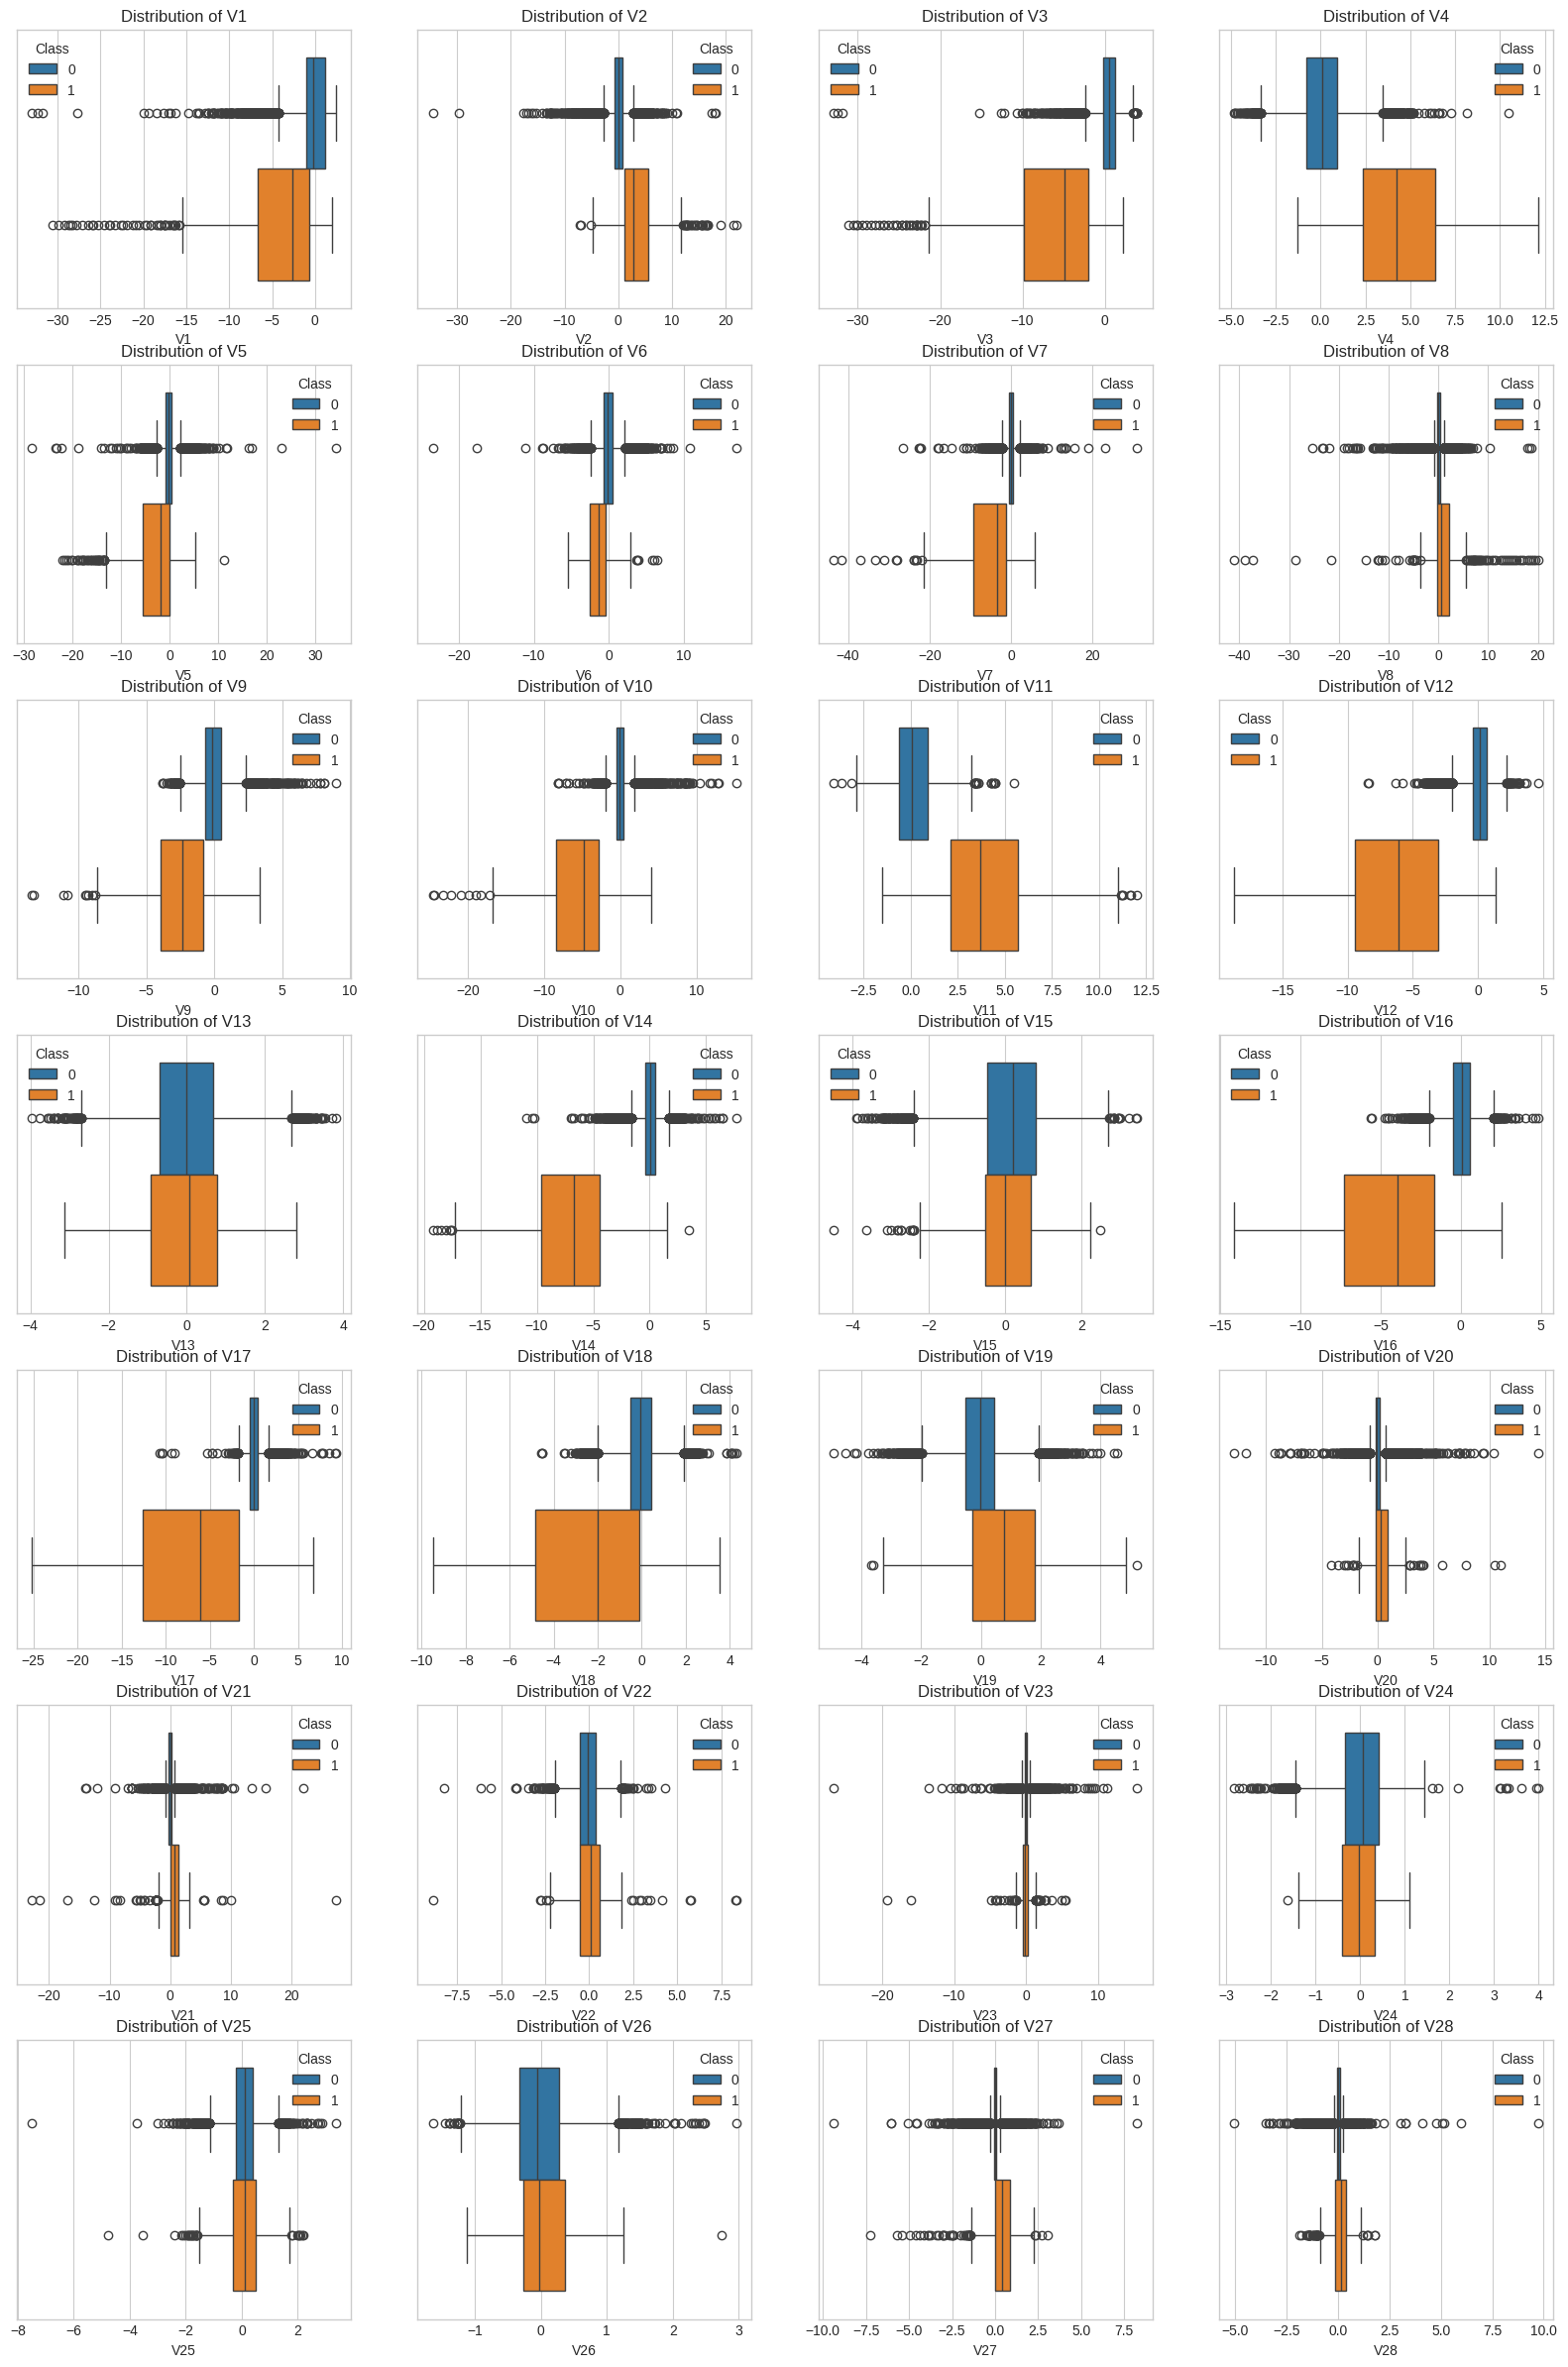

In [167]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Class', 'Amount']).columns):
    sns.boxplot(data=sample, x=col, ax=ax, hue = 'Class')
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_boxplots_unclipped.png', bbox_inches='tight', facecolor='white')

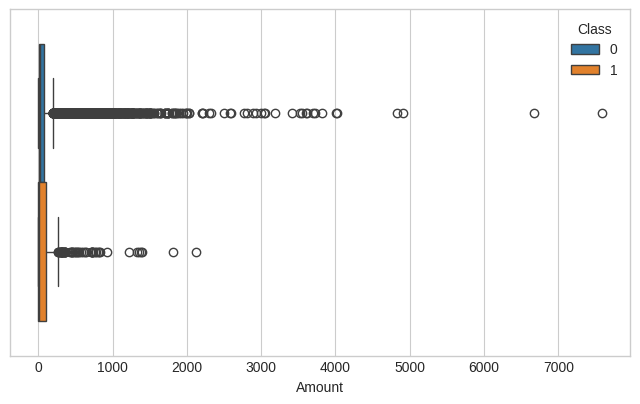

In [168]:
plt.figure(figsize=(8,4.5))
sns.boxplot(data=sample, x='Amount', hue = 'Class')
plt.savefig('../reports/figures/amount_boxplot_unclipped.png', bbox_inches='tight', facecolor='white')
plt.show()

The box plots show that some of the features are skewed, and some of the features have lots of outliers. The skewness of transaction amounts is to be expected, however the amount of outliers is much larger for the legitimate transactions than the fraudulent transactions for all of the features. Thus, we can keep the outliers as they may provide some indication as to which transactions are more likely to be fraudulent. We can check this by seeing percentages of outliers in each class.

In [169]:
def is_outlier(series):
    q1 = sample[series.name].quantile(0.25)
    q3 = sample[series.name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).astype(int)

In [170]:
fraud_sample = (sample[sample.Class == 1]).drop(['Class', 'Hour', 'Amount'], axis=1)

fraud_sample.apply(is_outlier).sum().sum() * 100 / fraud_sample.size

46.005639097744364

In [171]:
normal_sample = (sample[sample.Class == 0]).drop(['Class', 'Hour', 'Amount'], axis=1)

normal_sample.apply(is_outlier).sum().sum() * 100 / normal_sample.size

4.198018730038434

Here, we see that 46% of the values for the fraudulent transactions are outliers with respect to the entire dataset, whereas only 4% are for the legitimate transactions.

In [172]:
sample.drop(columns=['Class']).skew()

V1       -4.549814
V2       -0.263669
V3       -6.315547
V4        1.341186
V5       -2.679864
V6        0.614678
V7       -6.743738
V8       -5.213484
V9       -0.410280
V10      -3.863326
V11       1.793838
V12      -4.921517
V13       0.065865
V14      -4.930210
V15      -0.486302
V16      -3.968062
V17      -7.041672
V18      -1.989171
V19       0.121941
V20       1.519343
V21       1.516078
V22      -0.105206
V23      -5.390304
V24      -0.563055
V25      -0.681412
V26       0.628268
V27      -2.627857
V28       2.306823
Amount    9.577243
Hour     -0.231489
dtype: float64

We can clip the outliers to see if the values given for skewness have been largely affected by outliers. We will use $Q_1 - 1.5 \times \text{IQR}$ for the lower bound, and $Q_3 + 1.5 \times \text{IQR}$ for the upper bound, given that those are the boundaries used for outliers in the box plots.

In [173]:
def clip_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return series.clip(lower_bound, upper_bound)

In [174]:
clipped_sample = sample.drop(columns=['Class']).apply(clip_outliers).join(sample['Class'])
clipped_sample.skew()

V1       -0.756814
V2       -0.088125
V3       -0.558272
V4        0.217788
V5        0.200551
V6        0.536067
V7       -0.149315
V8        0.156826
V9        0.071564
V10       0.076133
V11       0.279917
V12      -0.608791
V13      -0.058647
V14      -0.251991
V15      -0.407664
V16      -0.395523
V17       0.249459
V18      -0.046983
V19      -0.014672
V20       0.295496
V21       0.154427
V22      -0.071158
V23       0.131105
V24      -0.554200
V25      -0.249969
V26       0.522356
V27       0.064658
V28      -0.134932
Amount    1.196945
Hour     -0.131777
Class     7.032952
dtype: float64

Now, the data is much less skewed, but we can examine what happened to the distributions.

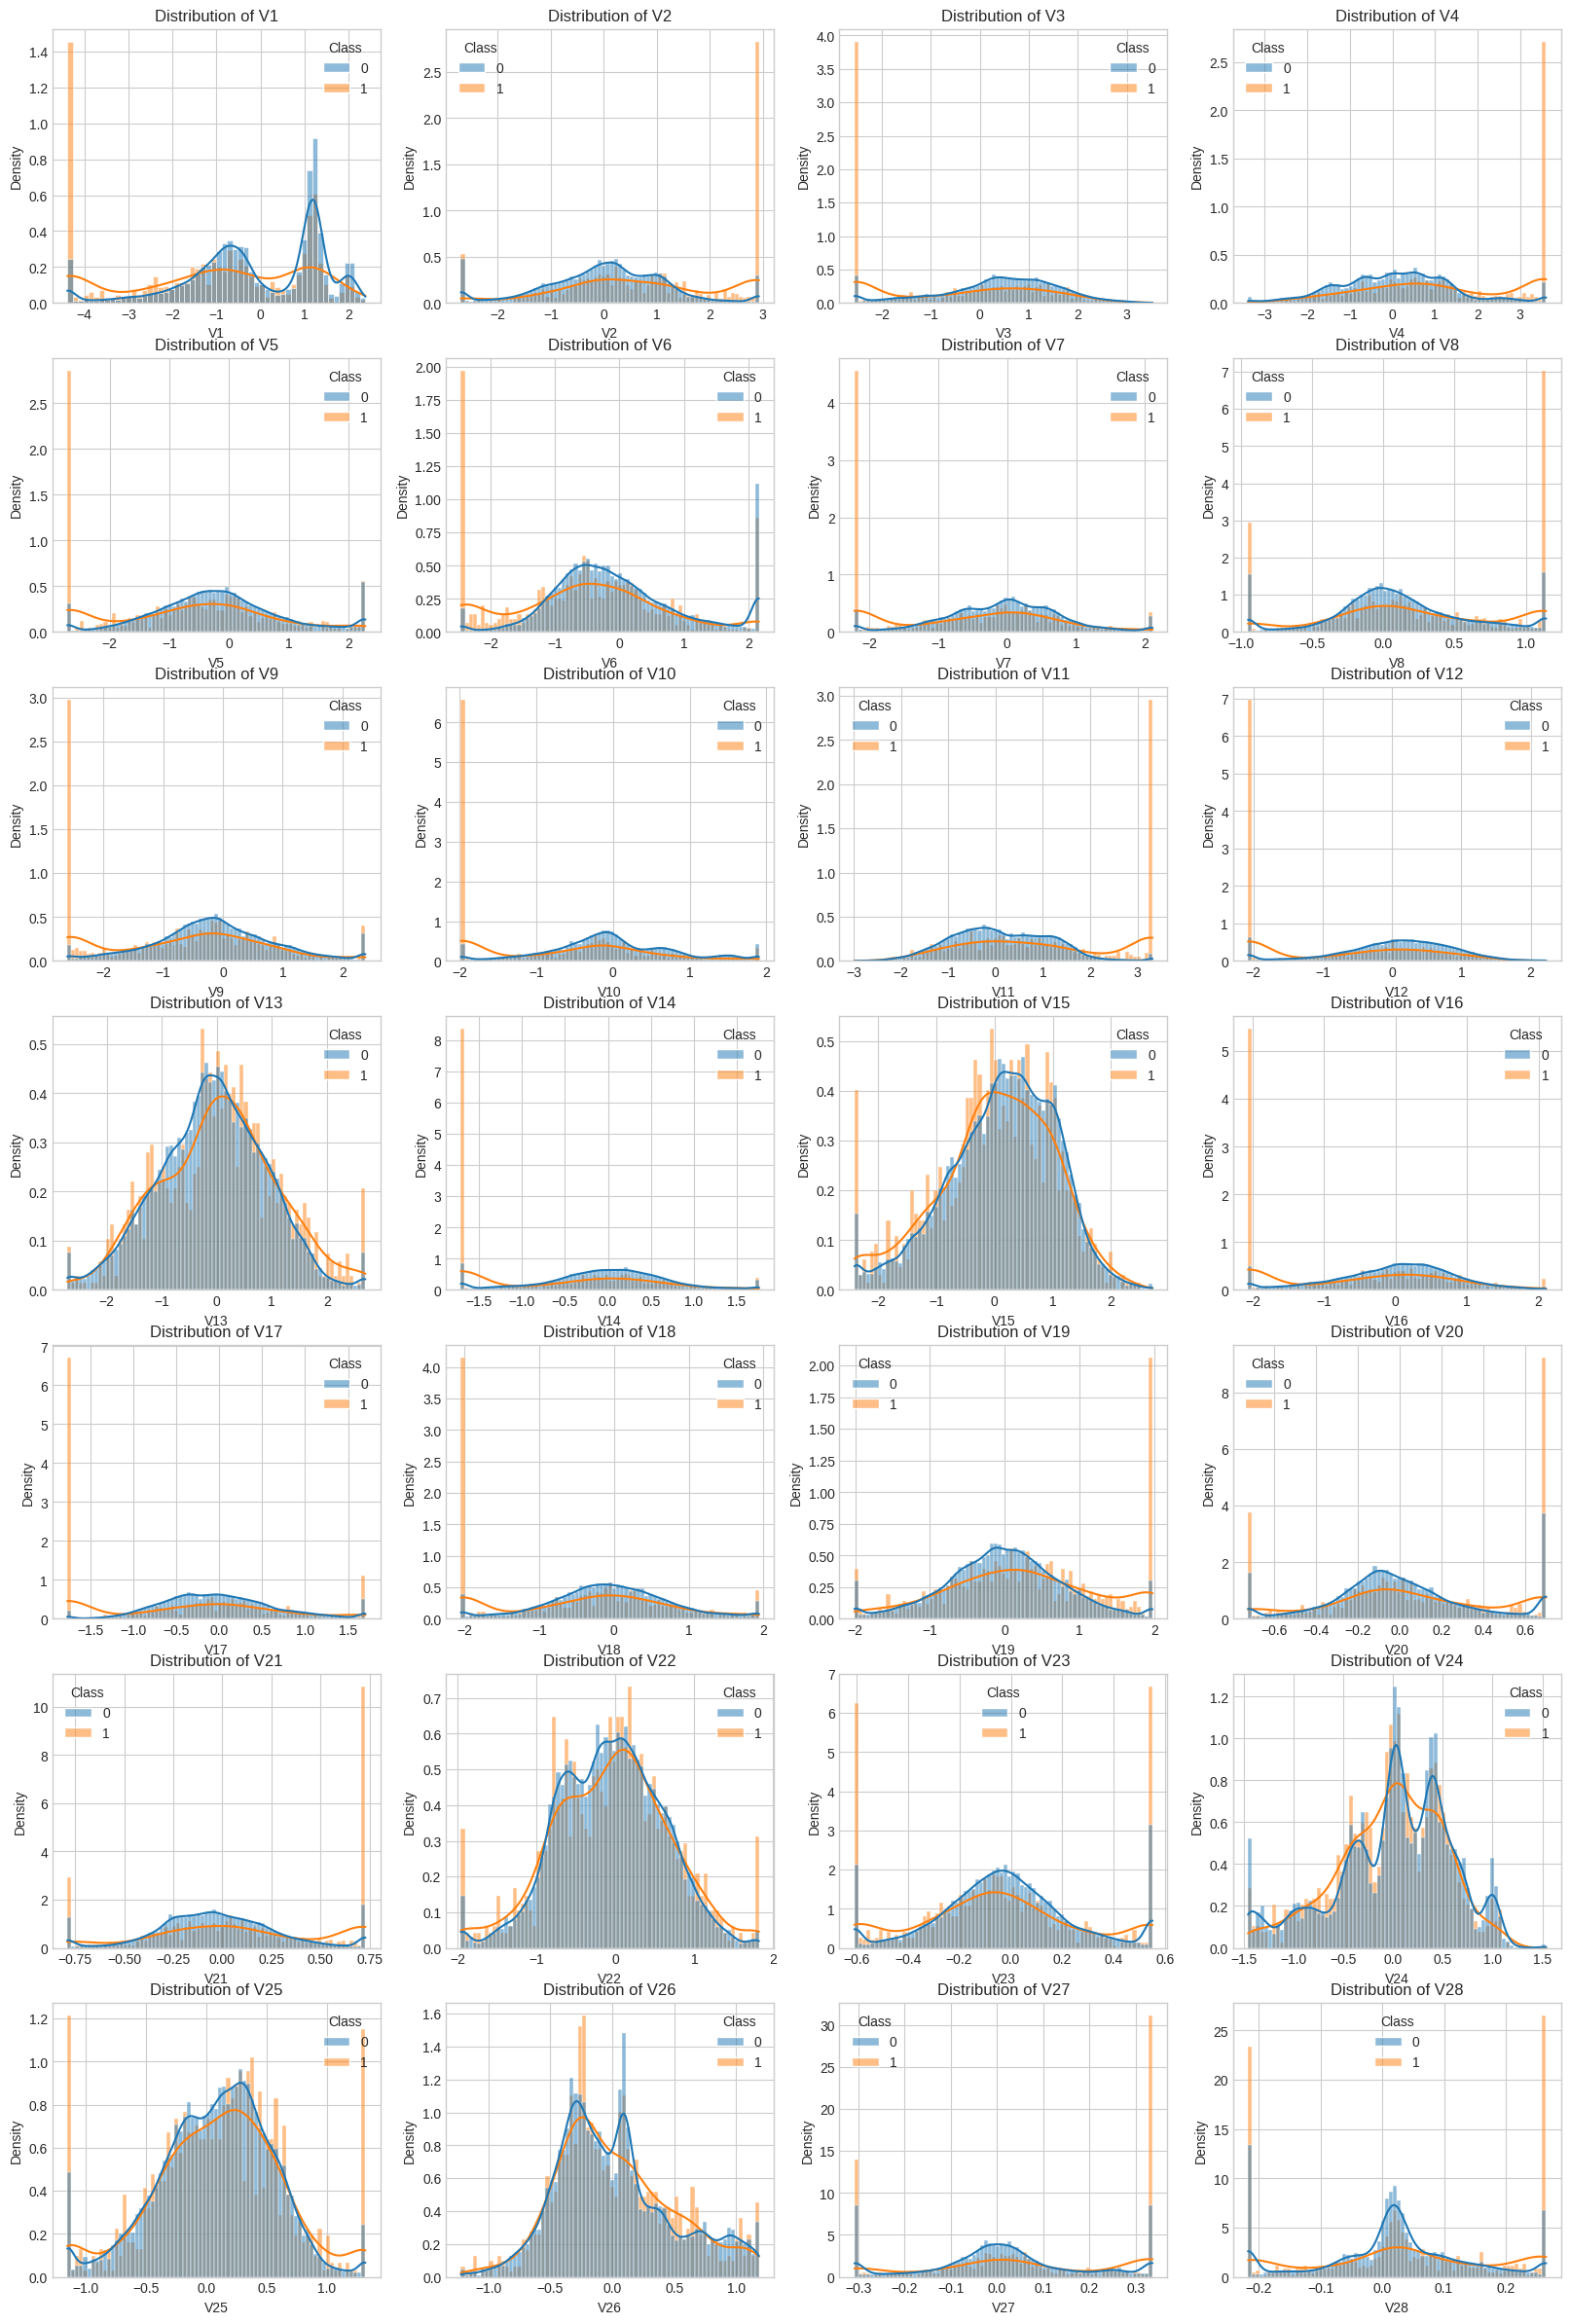

In [175]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Class']).columns):
    sns.histplot(data=clipped_sample, x=col, kde=True, ax=ax, hue = 'Class', stat='density', common_norm=False)
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_distributions_clipped.png', bbox_inches='tight', facecolor='white')

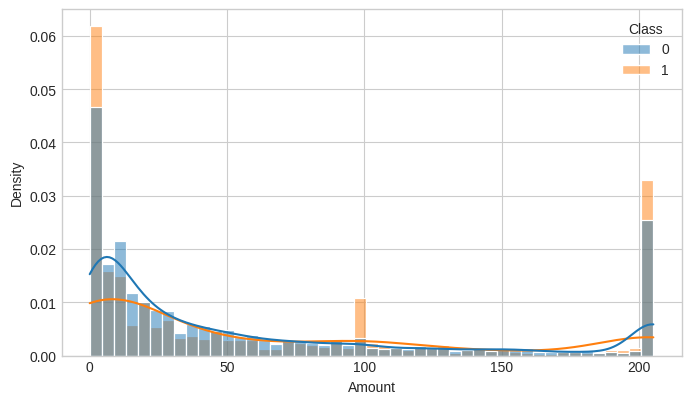

In [176]:
plt.figure(figsize=(8,4.5))
sns.histplot(data=clipped_sample, x='Amount', kde=True, hue = 'Class', stat='density', common_norm=False)
plt.savefig('../reports/figures/amount_distribution_clipped.png', bbox_inches='tight', facecolor='white')
plt.show()

After clipping the dataset, the boundary values that outliers were clipped to have a very high density, particularly for the positive cases, which suggests that the extreme values may be very important in predicting fraudulent transactions.

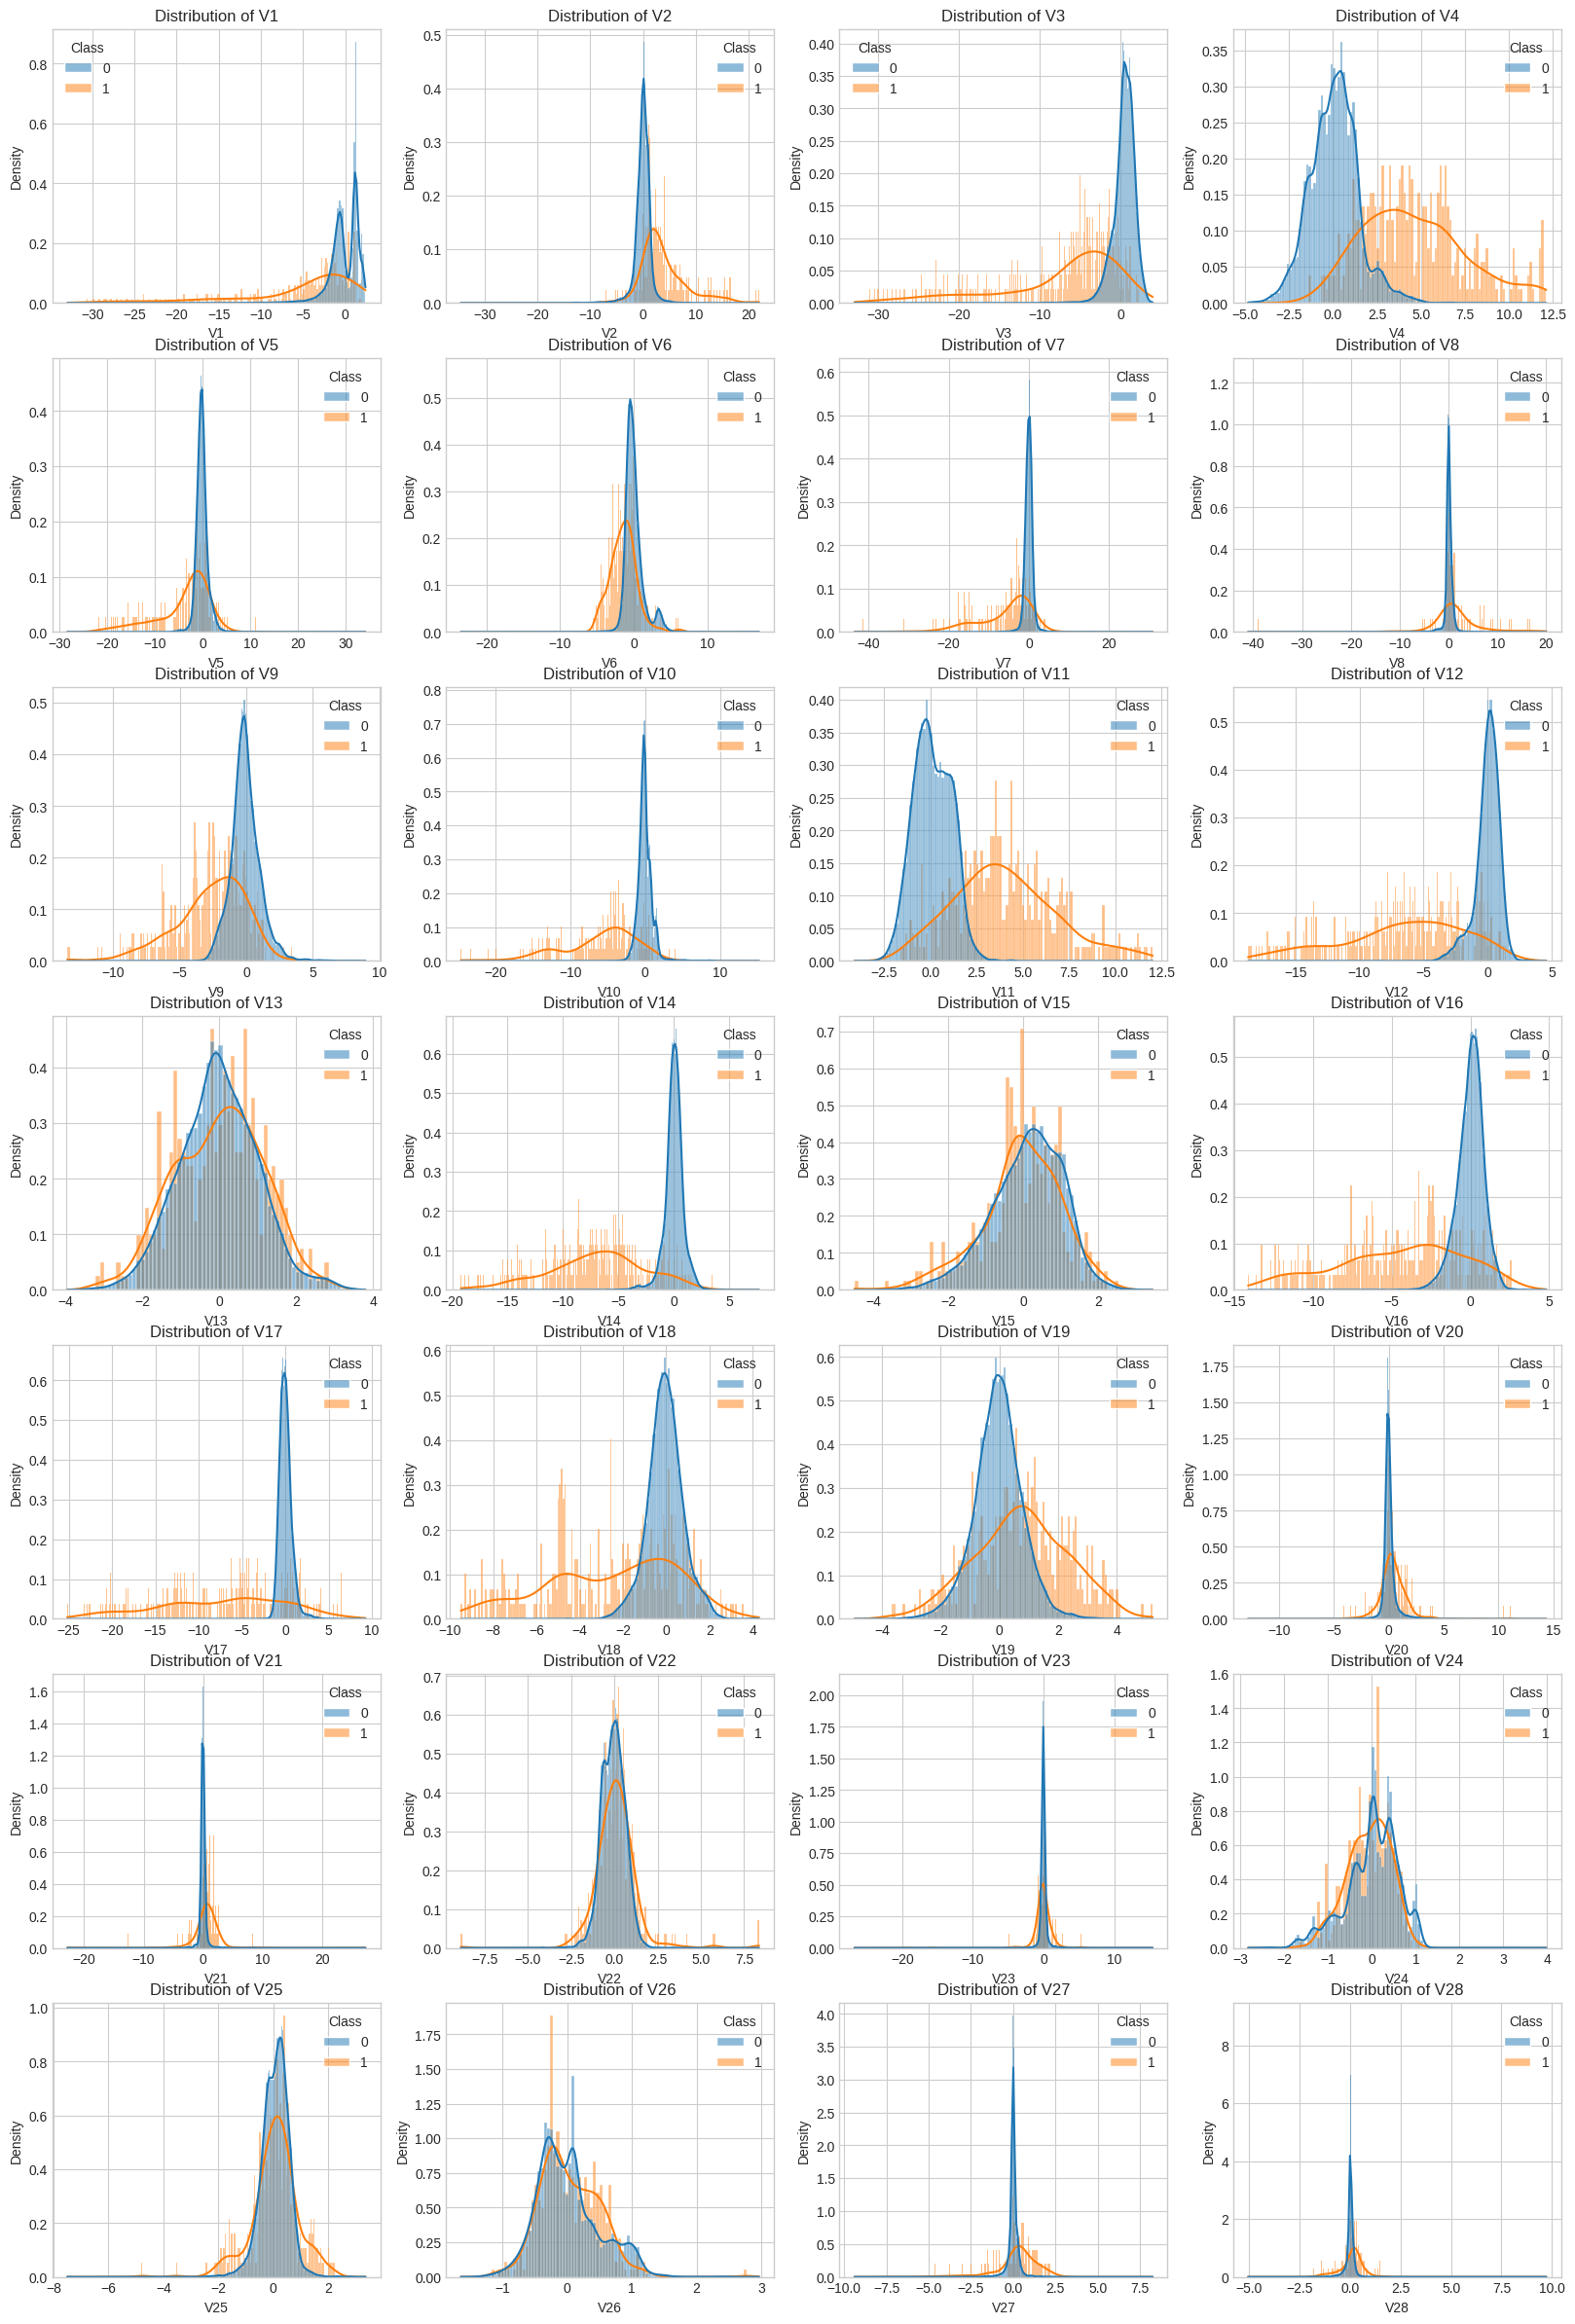

In [177]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), sample.drop(columns=['Class']).columns):
    sns.histplot(data=sample, x=col, kde=True, ax=ax, hue = 'Class', stat='density', common_norm=False)
    ax.set_title(f'Distribution of {col}')
fig.savefig('../reports/figures/feature_distributions_unclipped.png', bbox_inches='tight', facecolor='white')

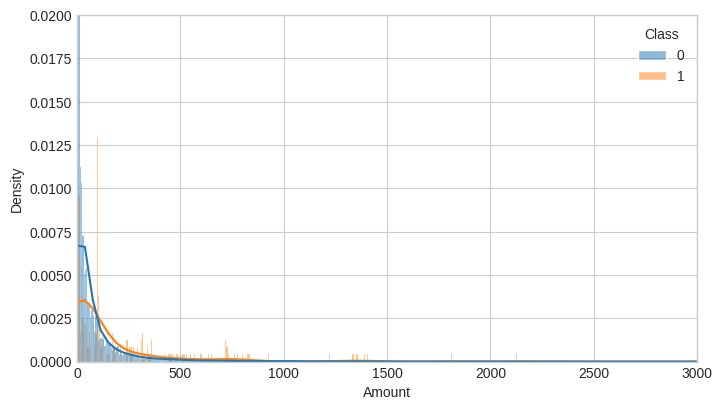

In [178]:
plt.figure(figsize=(8,4.5))
plt.xlim(0, 3000)
plt.ylim(0, 0.02)
sns.histplot(data=sample, x='Amount', kde=True, hue = 'Class', stat='density', common_norm=False)
plt.savefig('../reports/figures/amount_distribution_unclipped.png', bbox_inches='tight', facecolor='white')
plt.show()

The data is heavily skewed for Amount, but tree-based models will be able to handle this nonetheless.

The distributions for some of the principal components are very similar for both positive and negative cases, however some of them seem to have some differences. Some seem to be wider for positive cases than for negative cases, so we can use Levene's test to compare variances. The peaks of the distributions are also quite different for some of the principal components, so we can use Mann-Whitney's U test to check for differences in central tendency.

In [179]:
levene_results = pd.DataFrame(columns = ['Feature', 'Statistic', 'p-value'])
for col in sample.drop(columns=['Class']).columns:
    stat, p = sps.levene(sample_negative[col], sample_positive[col])
    levene_results.loc[len(levene_results)] = [col, stat, p]
levene_results['is_significant'] = levene_results['p-value'] < 0.05
levene_results

,Feature,Statistic,p-value,is_significant
0,V1,1796.537712,0.000000e+00,True
1,V2,850.478740,2.816333e-182,True
2,V3,3905.419669,0.000000e+00,True
3,V4,797.059935,3.176153e-171,True
4,V5,2200.557354,0.000000e+00,True
5,V6,93.482798,4.699586e-22,True
6,V7,4438.737213,0.000000e+00,True
7,V8,1507.265819,2.324136e-315,True
8,V9,888.701410,3.657873e-190,True
9,V10,3987.831119,0.000000e+00,True


The only features that have no significant difference between the variances of positive and negative cases are `V15` and `V26`.

In [180]:
mwu_results = pd.DataFrame(columns = ['Feature', 'Statistic', 'p-value'])
for col in sample.drop(columns=['Class']).columns:
    stat, p = sps.mannwhitneyu(sample_negative[col], sample_positive[col])
    mwu_results.loc[len(mwu_results)] = [col, stat, p]
mwu_results['is_significant'] = mwu_results['p-value'] < 0.05
mwu_results

,Feature,Statistic,p-value,is_significant
0,V1,4814983.0,2.730780e-89,True
1,V2,797483.0,8.931924e-133,True
2,V3,5565517.0,6.549936e-177,True
3,V4,382788.0,2.027637e-186,True
4,V5,4441183.0,7.505944e-57,True
5,V6,4644683.0,1.374196e-73,True
6,V7,5044646.0,6.513640e-113,True
7,V8,2042784.0,9.168434e-27,True
8,V9,4996165.0,1.082778e-107,True
9,V10,5524903.0,2.120949e-171,True


Given that our data has unequal variance between positive and negative cases, the results of the Mann-Whitney's U test only tells us that the distributions differ, but we can compare medians and variances to check where the differences lie.

In [181]:
def percentage_change(old, new):
    try:
        return ((new - old) / abs(old)) * 100
    except ZeroDivisionError:
        return math.inf

In [182]:
differences = pd.concat([sample_negative.drop(columns=['Class']).var(), 
           sample_positive.drop(columns=['Class']).var(),
           sample_negative.drop(columns=['Class']).median(),
           sample_positive.drop(columns=['Class']).median()], axis=1, keys=['Negative Variance', 'Positive Variance', 'Negative Median', 'Positive Median'])

differences['Variance % Change'] = differences.apply(lambda row: percentage_change(row['Negative Variance'], row['Positive Variance']), axis=1)
differences['Median % Change'] = differences.apply(lambda row: percentage_change(row['Negative Median'], row['Positive Median']), axis=1)

differences

,Negative Variance,Positive Variance,Negative Median,Positive Median,Variance % Change,Median % Change
V1,3.361890,49.965828,-0.190951,-2.609270,1386.242119,-1266.456898
V2,2.464533,18.535656,0.087311,2.767811,652.095955,3070.059716
V3,1.941155,56.788857,0.550134,-4.860293,2825.519611,-983.473903
V4,1.861476,8.772209,0.096077,4.258196,371.250250,4332.053453
V5,1.866204,30.576400,-0.210193,-1.926026,1538.427213,-816.314452
V6,1.656866,3.180868,-0.210179,-1.352604,91.981020,-543.547730
V7,1.372749,54.098353,-0.011568,-3.350226,3840.876802,-28860.709404
V8,1.264669,37.660410,0.054842,0.664233,2877.887443,1111.178582
V9,1.214722,6.917996,-0.130401,-2.333107,469.512453,-1689.183740
V10,1.053999,24.817400,-0.086420,-4.779971,2254.595346,-5431.062250


Here, we can see that for the majority of the features, both variance and median are very different for positive and negative cases.

In [183]:
mwu_results[~mwu_results['is_significant']]['Feature']

12    V13
24    V25
25    V26
Name: Feature, dtype: object

Since `V26` shows no significant difference in both median and variance between the positive and negative cases, it suggests that on its own, it may be a bad predictor of whether a transaction is fraudulent or not.

We can now check for any important temporal trends. Since the dataset only spans 48 hours, we can just aggregate based on the hour and check for trends based on the hour of the day.

In [184]:
positive_data_byhour = sample_positive.drop('Class', axis=1).groupby('Hour').mean()
negative_data_byhour = sample_negative.drop('Class', axis=1).groupby('Hour').mean()

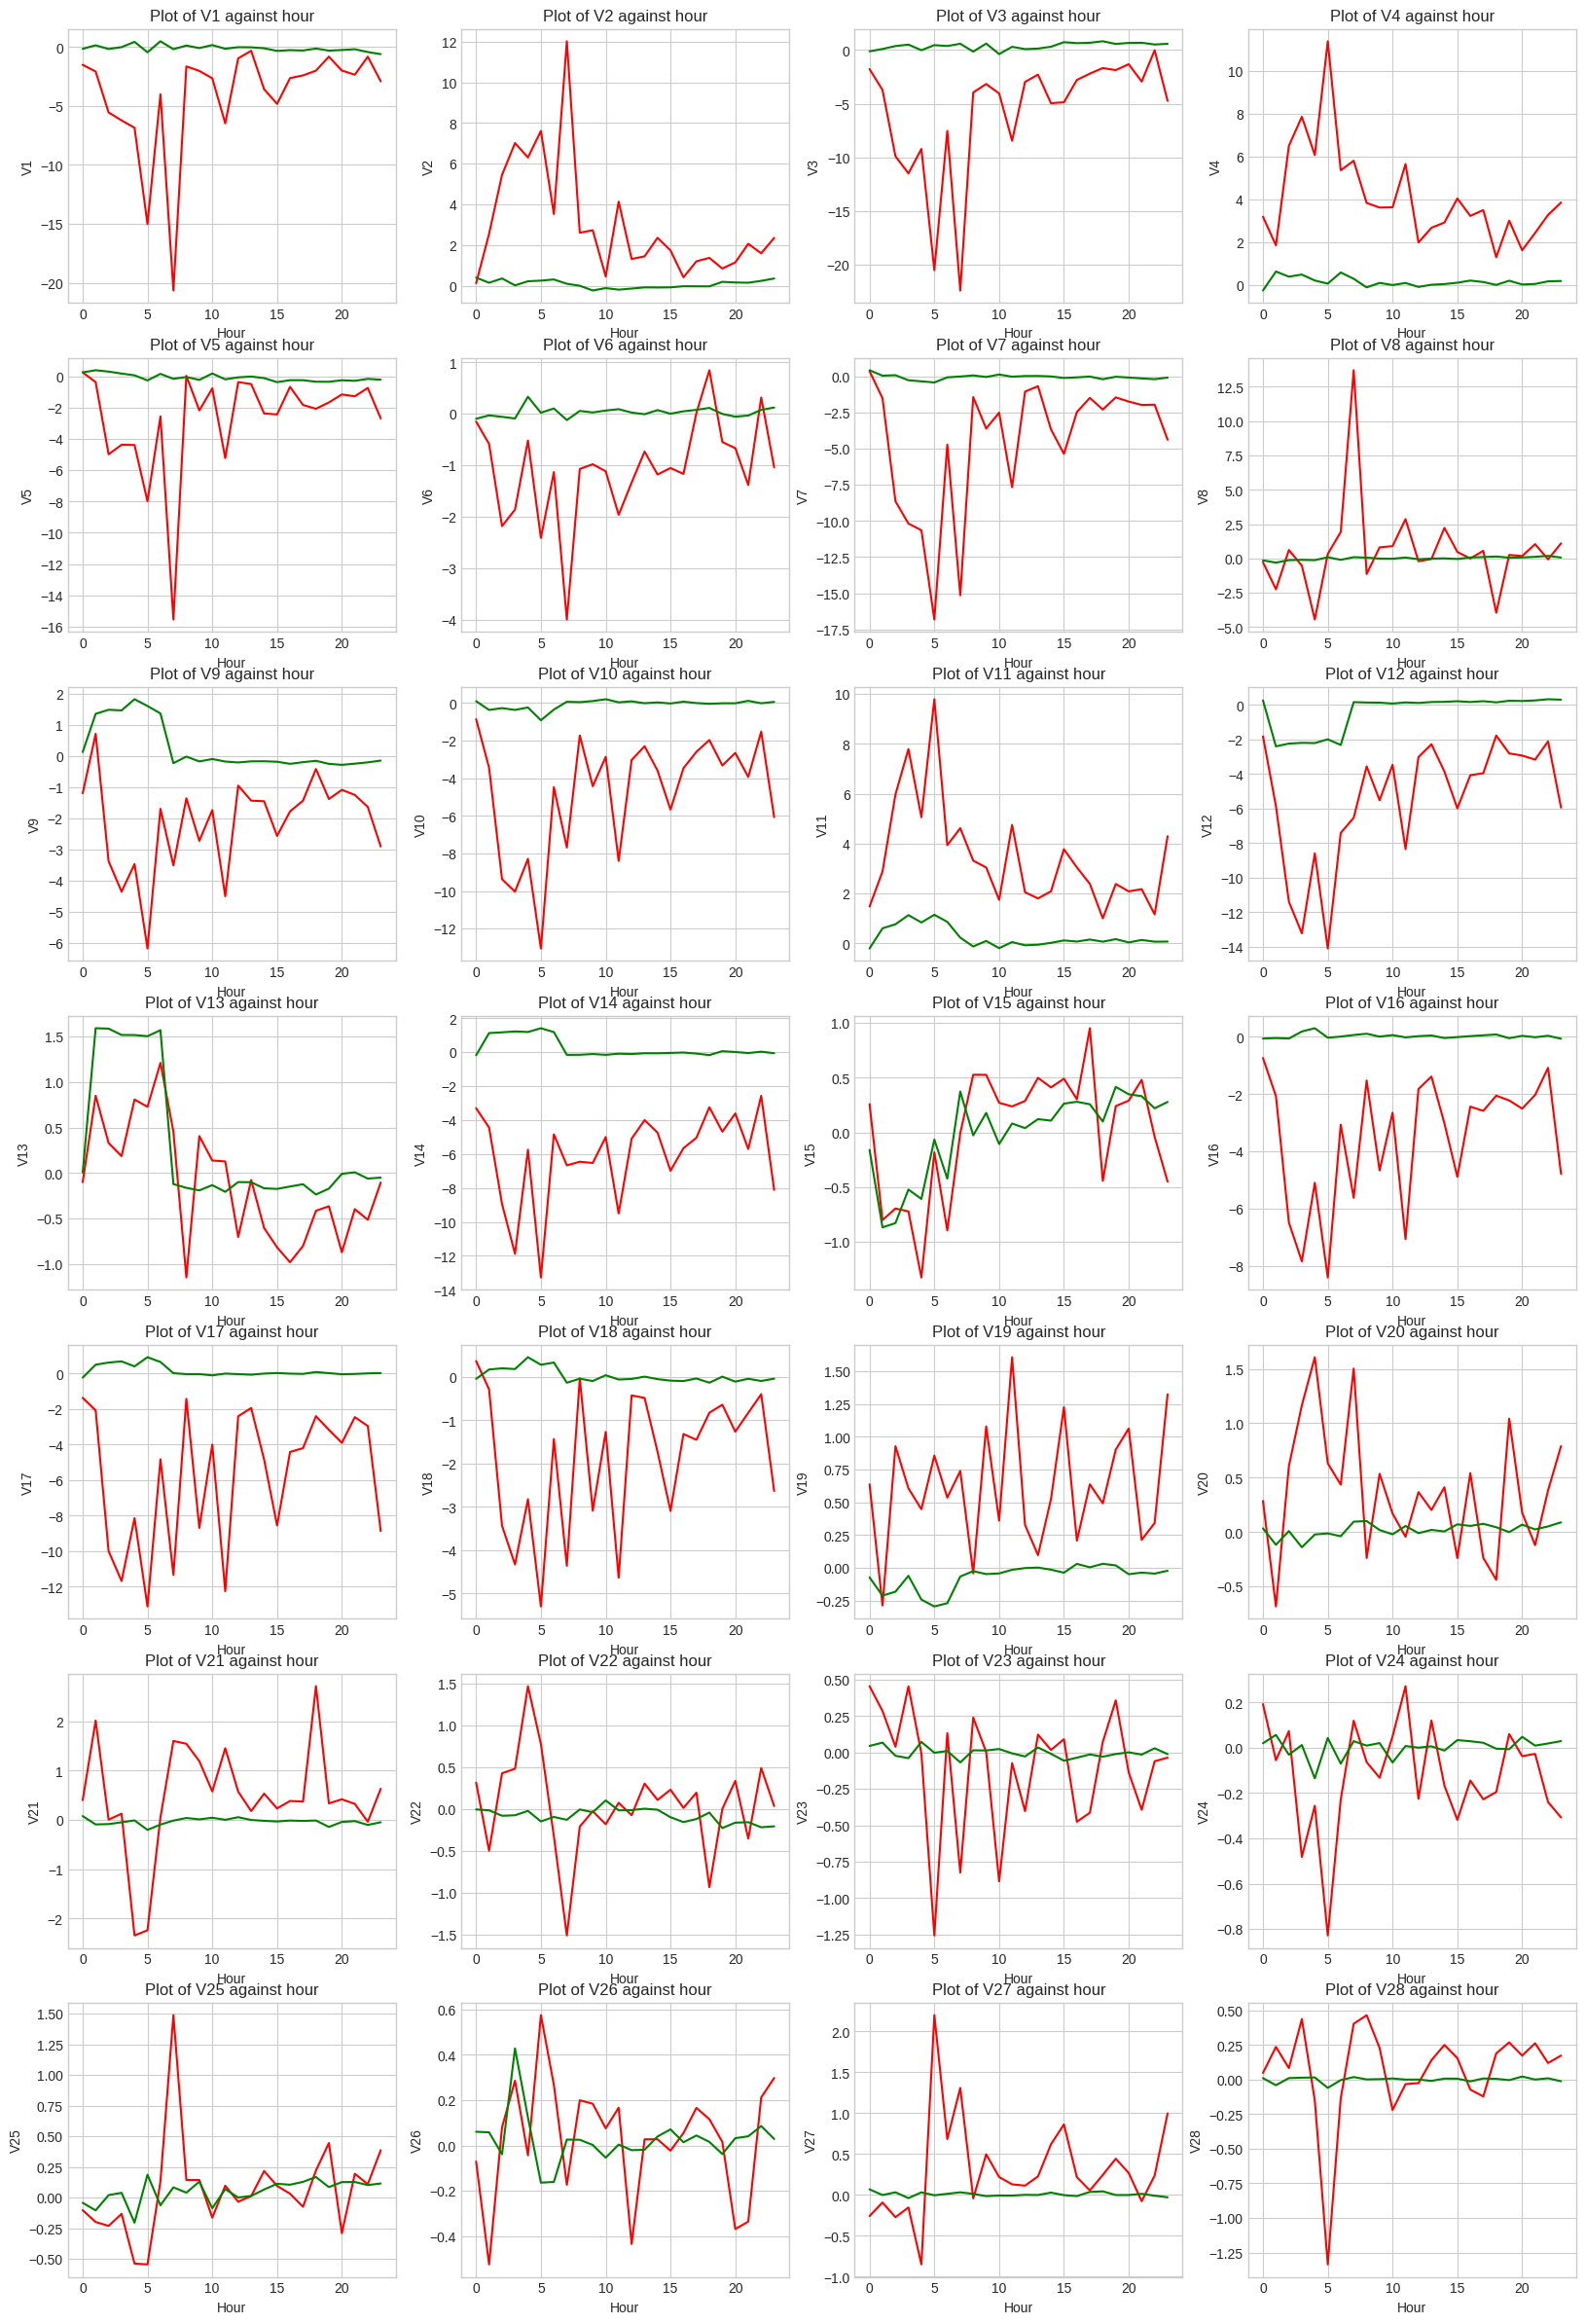

In [185]:
fig, axs = plt.subplots(7, 4, figsize=(20, 30))
for ax, col in zip(axs.flatten(), positive_data_byhour.columns):
    sns.lineplot(data=positive_data_byhour, x=positive_data_byhour.index, y=col, ax=ax, color='red')
    sns.lineplot(data=negative_data_byhour, x=negative_data_byhour.index, y=col, ax=ax, color='green')
    ax.set_title(f'Plot of {col} against hour')
fig.savefig('../reports/figures/time-plots.png', bbox_inches='tight', facecolor='white')

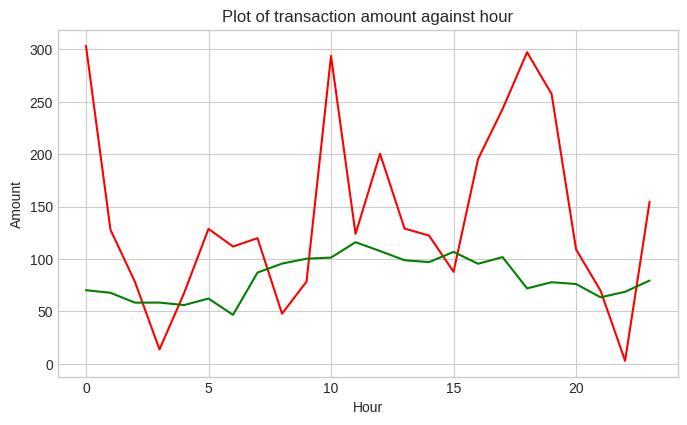

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(8,4.5))
ax.set_title('Plot of transaction amount against hour')
sns.lineplot(data=positive_data_byhour, x=positive_data_byhour.index, y='Amount', ax=ax, color='red')
sns.lineplot(data=negative_data_byhour, x=negative_data_byhour.index, y='Amount', ax=ax, color='green')
fig.savefig('../reports/figures/amount-time-plot.png', bbox_inches='tight', facecolor='white')

Here, we can see that the temporal trends differ between positive and negative cases for most features, so it shows that the `Hour` feature should provide useful information for the model.

### Bivariate correlation analysis

Although the principal components are independent of each other and have no correlation between them, there may be useful correlations that we see within the classes.

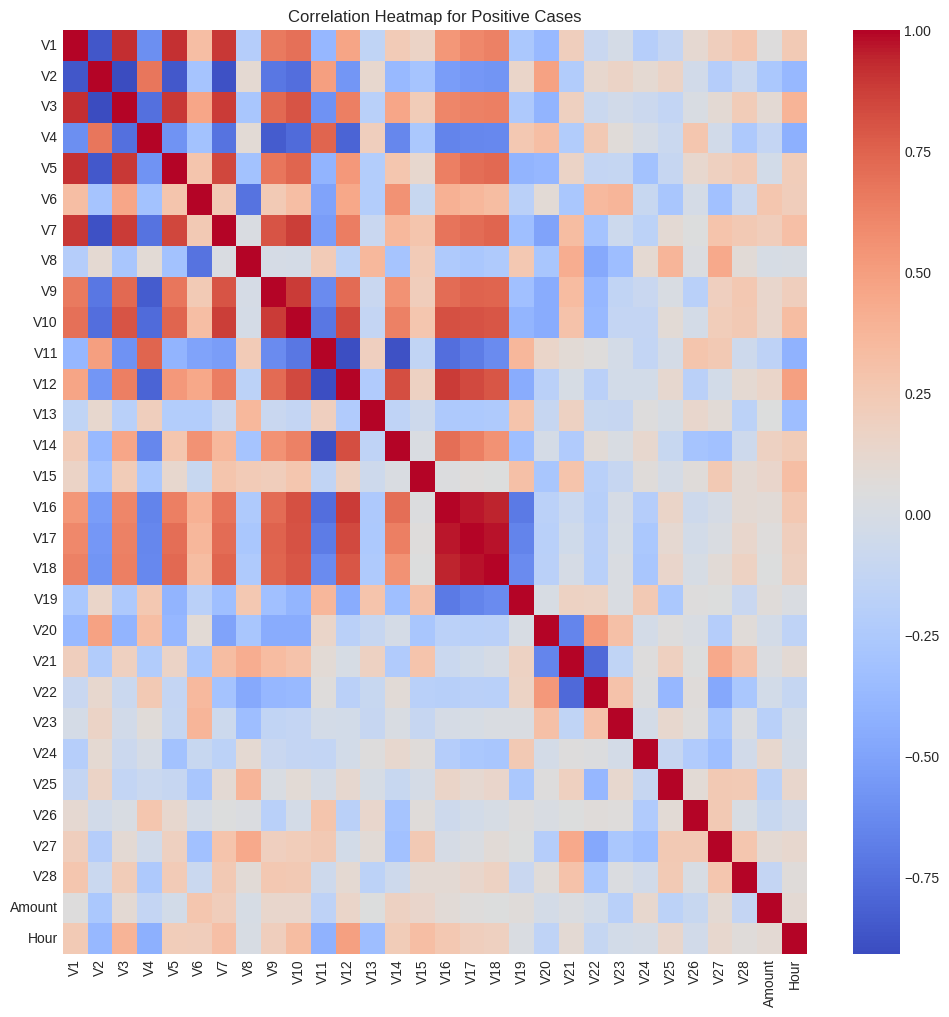

In [188]:
plt.figure(figsize=(12,12))
plt.title('Correlation Heatmap for Positive Cases')
sns.heatmap(sample_positive.drop(columns=['Class']).corr(), cmap='coolwarm')
plt.savefig('../reports/figures/correlation_heatmap_positive.png', bbox_inches='tight', facecolor='white')
plt.show()

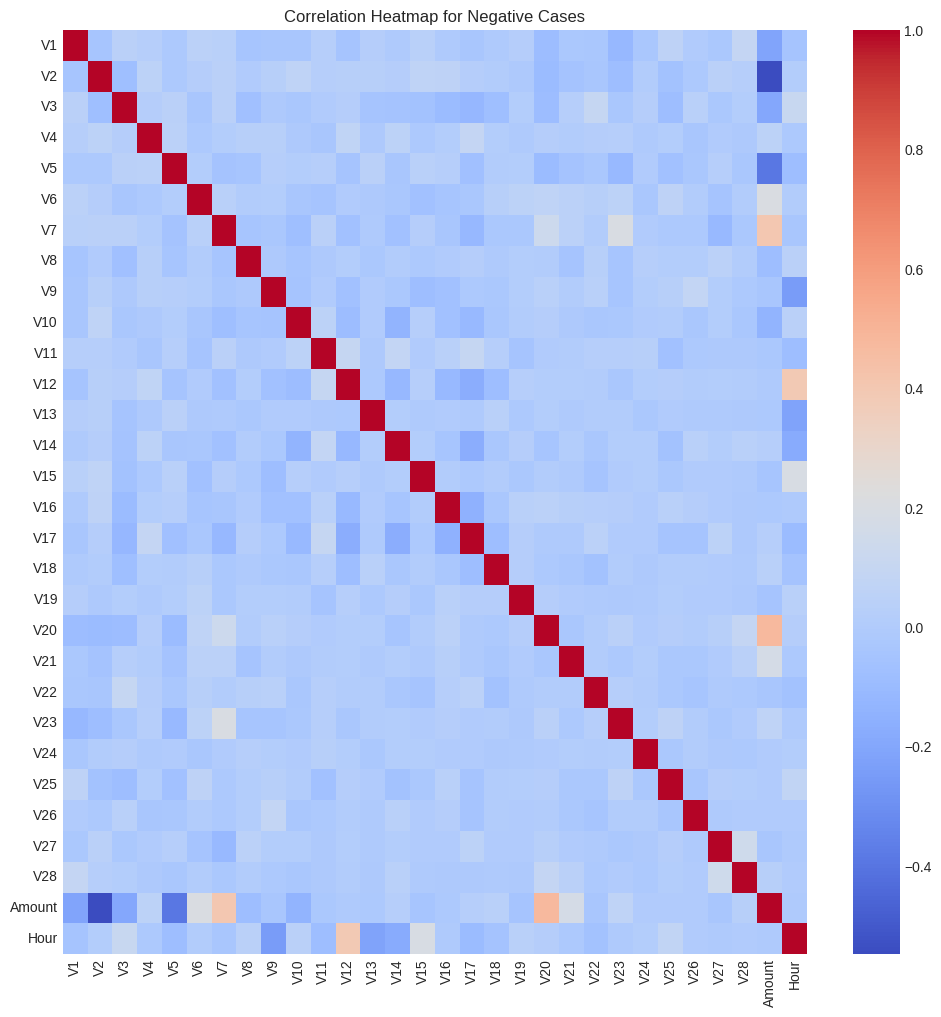

In [189]:
plt.figure(figsize=(12,12))
plt.title('Correlation Heatmap for Negative Cases')
sns.heatmap(sample_negative.drop(columns=['Class']).corr(), cmap='coolwarm')
plt.savefig('../reports/figures/correlation_heatmap_negative.png', bbox_inches='tight', facecolor='white')
plt.show()

We can immediately see that the features for the negative cases are far less correlated than the features for the positive cases.

## Key Takeaways
- The data has a lot of outliers, and removing them may reduce predictive power, as the outliers seemed to be more pronounced with the positive cases.
- The data is heavily imbalanced between positive and negative cases, so synthetic data generation may be necessary for the training data.
- There are combinations of features that are correlated with each other for the positive cases, so it is important to use a model that can deal with these interactions between features.
- Extracting the hour feature from the time elapsed is useful for the modelling.